In [1]:
# # Summary
# 
# Lets fit the models to the actual data.

# ---
# # Setup

# @title Imports
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence, plot_objective, plot_evaluations



from popy.simulation_tools import *
from popy.io_tools import load_behavior, load_behavior_yuri
from popy.behavior_data_tools import *
from popy.plotting.plotting_tools import *

from simulation_helpers import simulate_agent, estimate_ll, fit_simulate, estimate_rr


# data loading

def get_data_custom(monkey):
    if monkey in ['ka', 'po']:
        behav_monkey = load_behavior(monkey)
        behav_monkey = drop_time_fields(behav_monkey)
    elif monkey in ['yu_sham', 'yu_DCZ']:
        behav_monkey = load_behavior_yuri()
        behav_monkey = behav_monkey.loc[behav_monkey['monkey'] == monkey]
    else:
        raise ValueError(f'Unknown monkey: {monkey}')
    
    behav_monkey = add_switch_info(behav_monkey)
    behav_monkey = convert_column_format(behav_monkey, original='behavior')

    behav_monkey = behav_monkey.dropna()

    return behav_monkey

def res_to_dataframe(results):
    res_all = pd.DataFrame.from_dict(results, orient='index').reset_index()  # convert to dataframe
    res_all = res_all.rename(columns={'index': 'Model'})  # rename index column to Model

    cols = list(res_all.columns)
    first_columns = ['Model', 'epsilon', 'alpha', 'alpha_unchosen', 'beta', 'V0', 
                     'forgetting_rate', 'forgetting_threshold', 
                     'stickyness_bias', 
                     'b1', 'b2', 'b3', 
                     'abandoned_bias', 'abandoned_decay']
    present = [c for c in first_columns if c in cols]
    rest = [c for c in cols if c not in present]
    new_columns = present + rest

    return res_all[new_columns]

def behavs_to_dataframe(behaviors_simulated, monkey):
    # combine all behaviors into one dataframe
    behavs = []

    # Process simulations: start with the real behavior
    behav_monkey = behaviors_simulated[f'MONKEY {monkey.upper()}']
    behav_monkey = behav_monkey.drop(columns=['switch'])
    behav_monkey['model'] = 'recording'
    behavs.append(behav_monkey)

    # then add the simulated behaviors
    for key, behav_temp in behaviors_simulated.items():
        if key != f'MONKEY {monkey.upper()}':
            behav_temp['monkey'] = monkey
            behav_temp['session'] = 0
            behav_temp['model'] = key
            behavs.append(behav_temp)

    behaviors_simulated_all = pd.concat(behavs, axis=0)

    # reorder columns
    cols = ['monkey', 'model', 'session'] + [col for col in behav_monkey.columns if col not in ['monkey', 'session', 'model']]
    behaviors_simulated_all = behaviors_simulated_all[cols]

    # reset index
    behaviors_simulated_all = behaviors_simulated_all.reset_index(drop=True)

    return behaviors_simulated_all

In [2]:
monkey = 'ka'
behav_monkey = get_data_custom(monkey)

env = gym.make("zsombi/monkey-bandit-task-v0", n_arms=3, max_episode_steps=100_000)


In [17]:
# ### Simple RL agent - forgetting + stickyness
model_name = 'Standard RL - forgetting + stickyness'
agent_class = QLearner
fixed_params = {'structure_aware': False}
params = {
    'alpha': 0.5488156308474463,
    'beta': 12.099785223900664,
    'forgetting_rate': 0.7157953000779667,
    'forgetting_threshold': 0.18817207353332138,
    'stickyness_bias': 1.4959892155969738,
}

ll = estimate_ll(agent_class, params, behav_monkey, fixed_params)
rr = estimate_rr(agent_class, params, env, fixed_params)

behavior_simulated = simulate_agent(
        agent_class=agent_class, 
        params=params,
        env=env,
        fixed_params=fixed_params,
        behavioral_variables=['q_values'],
    )

lpt = np.exp(ll / len(behav_monkey))
reward_rate = behavior_simulated['reward'].mean()
proba_best = (behavior_simulated['action'] == behavior_simulated['best_arm']).mean()

# print results
print(f"Model: {model_name}")
print(f"LPT: {lpt:.3f}")
print(f"Reward Rate: {reward_rate:.3f}")
print(f"Probability of choosing the best arm: {proba_best:.3f}")
# ---

Model: Standard RL - forgetting + stickyness
LPT: 0.775
Reward Rate: 0.548
Probability of choosing the best arm: 0.712


In [14]:
behavior_simulated = convert_column_format(behavior_simulated, original='simulation')
behavior_simulated['monkey'] = monkey
behavior_simulated['session'] = 0
behavior_simulated['Q_1'] = behavior_simulated['q_values'].apply(lambda x: x[0])
behavior_simulated['Q_2'] = behavior_simulated['q_values'].apply(lambda x: x[1])
behavior_simulated['Q_3'] = behavior_simulated['q_values'].apply(lambda x: x[2])

behavior_simulated

,trial_id,block_id,best_target,target,feedback,q_values,monkey,session,Q_1,Q_2,Q_3
0,0,0,1,3,0.0,"[0.33333334, 0.33333334, 0.33333334]",ka,0,0.333333,0.333333,0.333333
1,1,0,1,1,1.0,"[0.22942759, 0.22942759, 0.1503948]",ka,0,0.229428,0.229428,0.150395
2,2,0,1,1,1.0,"[0.6523298, 0.19989708, 0.17743559]",ka,0,0.652330,0.199897,0.177436
3,3,0,1,1,1.0,"[0.84313667, 0.19150437, 0.18512072]",ka,0,0.843137,0.191504,0.185121
4,4,0,1,1,1.0,"[0.92922574, 0.18911913, 0.18730487]",ka,0,0.929226,0.189119,0.187305
...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,2497,2,2,1.0,"[0.18817207, 0.40048745, 0.18817207]",ka,0,0.188172,0.400487,0.188172
99996,99996,2497,2,2,1.0,"[0.18817207, 0.7295093, 0.18817207]",ka,0,0.188172,0.729509,0.188172
99997,99997,2497,2,2,1.0,"[0.18817207, 0.87795883, 0.18817207]",ka,0,0.188172,0.877959,0.188172
99998,99998,2497,2,2,1.0,"[0.18817207, 0.94493693, 0.18817207]",ka,0,0.188172,0.944937,0.188172


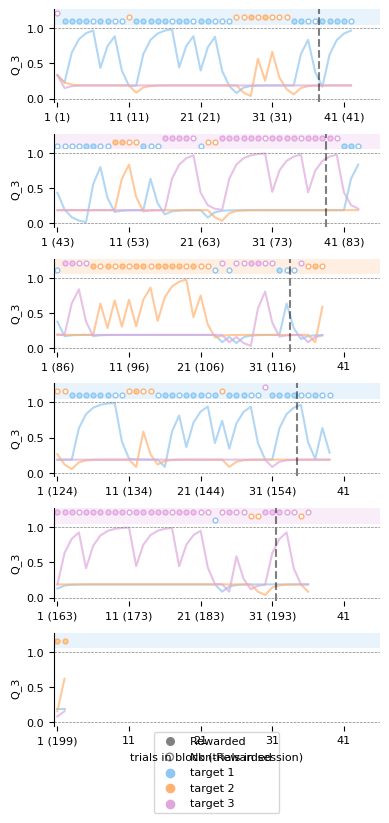

In [15]:
# plot behavior
##% imports
import pandas as pd
import matplotlib.pyplot as plt

from popy.io_tools import load_behavior, load_behavior_yuri, load_simulation
from popy.behavior_data_tools import *
from popy.plotting.plotting_tools import show_target_selection, show_target_selection_compact

# set fontsize to 8pt
plt.rcParams.update({'font.size': 8})

# target selection
#savedir = os.path.join('figs', 'example_session_compact.svg')
savedir = 'figs/example_session_compact_forage.svg'
show_target_selection_compact(behavior_simulated[:200],   # here we can put any behavior dataframe
                              format='poster',
                              background_values=['Q_1', 'Q_2', 'Q_3'],   # here we tell what variable to use as background - value in this case
                              title=None, #f'monkey: {monkey}, session: {session}', 
                              show=True, 
                              savedir=None)

In [19]:
# degeneracy: simulate foraging model over different alpha and v0
# ### Simple RL agent - forgetting + stickyness
model_name = 'Foraging'
agent_class = ForagingAgent
fixed_params = {'reset_on_switch': True}

params = {
    'beta': 12.099785223900664,    
}


alpha_range = np.linspace(0.01, 1, 10)
v0_range = np.linspace(0.0, 1, 10)
lpts = np.empty((len(alpha_range), len(v0_range)))
for alpha, v0 in itertools.product(alpha_range, v0_range):
    params['alpha'] = alpha
    params['V0'] = v0

    ll = estimate_ll(agent_class, params, behav_monkey, fixed_params)
    rr = estimate_rr(agent_class, params, env, fixed_params)

    behavior_simulated = simulate_agent(
            agent_class=agent_class, 
            params=params,
            env=env,
            fixed_params=fixed_params,
            behavioral_variables=['V'],
        )

    lpt = np.exp(ll / len(behav_monkey))
    lpts[np.where(alpha_range == alpha)[0][0], np.where(v0_range == v0)[0][0]] = lpt

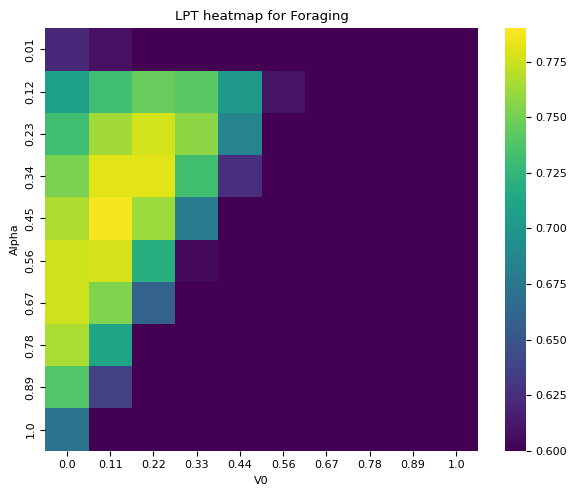

In [25]:
# plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(lpts, 
            xticklabels=np.round(v0_range, 2), 
            yticklabels=np.round(alpha_range, 2),
            cmap='viridis',
            vmin=0.6, vmax=.79)
plt.xlabel('V0')
plt.ylabel('Alpha')
plt.title(f'LPT heatmap for {model_name}')
plt.tight_layout()
plt.show()